# Notebook 04 - Sentiment Analysis and Named Entity Recognition

Applies VADER sentiment analysis and spaCy NER to the augmented sunscreen corpus, 
compares sentiment by brand, and analyses documents related to the ACCC case.

**Input:** `../data/processed/df_sunscreen_augmented.csv`  
**Output:** `../data/processed/df_sunscreen_final.csv`

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import nltk

nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer

import spacy
nlp = spacy.load('en_core_web_sm')

pd.set_option('display.max_colwidth', None)

print("All imports successful ✓")

All imports successful ✓


[nltk_data] Downloading package punkt_tab to /Users/giuly/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/giuly/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/giuly/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/giuly/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [63]:
df = pd.read_csv('../data/processed/df_sunscreen_augmented.csv')
print(f"Shape: {df.shape}")
print(f"\nContent types:\n{df['content_type'].value_counts()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
df.head(3)

Shape: (268, 12)

Content types:
content_type
comment    201
post        67
Name: count, dtype: int64

Missing values:
Post_id                0
Timestamp              0
Text                   0
Score                  0
subreddit              0
content_type           0
text_length          260
year                 260
text_clean           260
dominant_topic       260
dominant_subtopic    260
subtopic_label       260
dtype: int64


Post_id            Timestamp  \
0  rc7fq9  2021-12-09 02:28:00   
1  s205u0  2022-01-12 07:13:00   
2  znbymc  2022-12-16 11:11:00   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

In [64]:
# mark synthetic vs real
df['is_synthetic'] = df['text_clean'].isna()

In [65]:
# preprocessing
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

custom_stopwords = {
    'people', 'one', 'think', 'thing', 'use', 'make', 'way', 'even',
    'dont', 'thats', 'isnt', 'doesnt', 'cant', 'im', 'youre', 'theyre', 'arent',
    'u', 'ye', 'etc', 'really', 'still', 'much', 'many', 'lot', 'well',
    'good', 'great', 'better', 'got', 'put', 'go', 'come', 'take', 'try',
    'say', 'feel', 'mean', 'seem', 'look', 'start', 'end', 'keep', 'would',
    'want', 'need', 'know', 'help', 'find', 'work', 'used', 'using',
    'something', 'anything', 'everything', 'nothing', 'someone', 'like', 'get',
    'also', 'back', 'around', 'first', 'every', 'never', 'always',
    'maybe', 'probably', 'though', 'already', 'enough', 'little',
    'stuff', 'see', 'going', 'sure', 'actually', 'co',
    'right', 'yes', 'yeah', 'me', 'said', 'saying', 'didnt', 'wont',
    'things', 'ive', 'time', 'point', 'thank', 'making'
}

stop_words_extended = stop_words | custom_stopwords

In [66]:
# creating a function for cleaning the text using the customized stopwords
def preprocess_text(text):
    if pd.isna(text):
        return ''
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words_extended]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

# preprocessing the data
print("Preprocessing...")
df['text_clean'] = df['Text'].apply(preprocess_text)
print(f"Done. Empty texts: {(df['text_clean'] == '').sum()}")

Preprocessing...
Done. Empty texts: 0


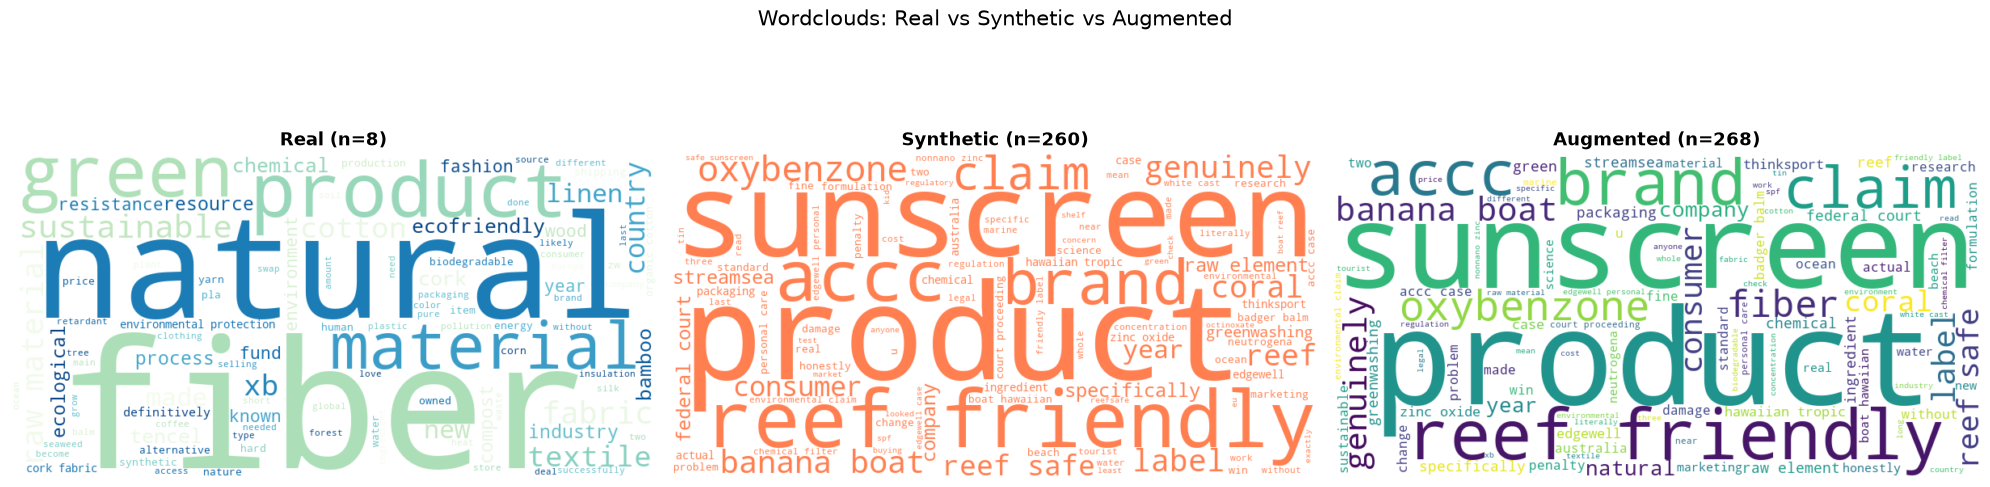

In [67]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

datasets = {
    'Real (n=8)': (df[df['is_synthetic']==False]['text_clean'], 'GnBu'),
    'Synthetic (n=260)': (df[df['is_synthetic']==True]['text_clean'], None),
    'Augmented (n=268)': (df['text_clean'], 'viridis')
}

for ax, (title, (texts, cmap)) in zip(axes, datasets.items()):
    text_all = ' '.join(texts)
    if cmap:
        wc = WordCloud(width=800, height=400, background_color='white',
                      colormap=cmap, max_words=100).generate(text_all)
    else:
        wc = WordCloud(width=800, height=400, background_color='white',
                      color_func=lambda *args, **kwargs: 'coral',
                      max_words=100).generate(text_all)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.suptitle('Wordclouds: Real vs Synthetic vs Augmented', fontsize=15)
plt.tight_layout()
plt.show()

In [68]:
for label, texts, cmap, color in [
    ('real', df[df['is_synthetic']==False]['text_clean'], 'GnBu', None),
    ('synthetic', df[df['is_synthetic']==True]['text_clean'], None, 'coral'),
    ('augmented', df['text_clean'], 'viridis', None),
]:
    text_all = ' '.join(texts)
    if cmap:
        wc = WordCloud(width=800, height=500, background_color='white',
                      colormap=cmap, max_words=100).generate(text_all)
    else:
        wc = WordCloud(width=800, height=500, background_color='white',
                      color_func=lambda *args, **kwargs: color,
                      max_words=100).generate(text_all)
    plt.figure(figsize=(10, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(f'../figures/wordcloud_{label}.png', dpi=150, bbox_inches='tight')
    plt.close()
    print(f"✓ wordcloud_{label}.png saved")

✓ wordcloud_real.png saved
✓ wordcloud_synthetic.png saved
✓ wordcloud_augmented.png saved


## Wordcloud Analysis: Real vs Synthetic vs Augmented

Three wordclouds were generated to visually compare the vocabulary 
distribution across the real, synthetic, and augmented datasets.

**Real (n=8):** vocabulary is broader and less focused, dominated by 
generic sustainability terms (*fiber*, *plastic*, *product*, *natural*). 
Sunscreen is present but not dominant, reflecting the scarcity of 
brand-specific content in the original Reddit data.

**Synthetic (n=260):** vocabulary is sharply focused on the target topic: 
*reef*, *friendly*, *sunscreen*, *accc*, *banana boat*, *oxybenzone* 
all feature prominently. The synthetic data successfully introduced 
the brand-specific and regulatory signal absent from the real subset.

**Augmented (n=268):** vocabulary reflects the combined corpus, 
with synthetic signal dominating due to the 260:8 ratio.

In [69]:
# VADER is a rule-based sentiment analyzer designed for social media text
# it returns 4 scores: positive, negative, neutral, and compound
# compound is the overall score: ranges from -1 (most negative) to +1 (most positive)
# thresholds: compound >= 0.05 = positive, <= -0.05 = negative, in between = neutral

sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    scores = sia.polarity_scores(text)
    compound = scores['compound']
    if compound >= 0.05:
        return 'positive'
    elif compound <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df['sentiment_score'] = df['Text'].apply(lambda x: sia.polarity_scores(x)['compound'])
df['sentiment_label'] = df['Text'].apply(get_sentiment)

print(df['sentiment_label'].value_counts())
print(f"\nMean compound score: {df['sentiment_score'].mean():.3f}")

sentiment_label
positive    181
negative     64
neutral      23
Name: count, dtype: int64

Mean compound score: 0.292


## Sentiment Analysis with VADER

VADER (Valence Aware Dictionary and sEntiment Reasoner) is a rule-based 
sentiment analyzer specifically designed for social media text. Unlike 
ML-based models, VADER uses a lexicon of words with pre-assigned valence 
scores and a set of grammatical rules to compute sentiment.

VADER was chosen for this analysis because:
- It is optimised for informal, short-form social media text (Reddit comments)
- It handles capitalisation, punctuation emphasis, and negations natively
- It requires no training data and no GPU - appropriate for a small dataset
- It is fast and interpretable

The compound score ranges from -1 (most negative) to +1 (most positive).
Classification thresholds follow the authors' official recommendation:
- compound >= 0.05 → positive
- compound <= -0.05 → negative
- otherwise → neutral

**Results:** 181 positive (67.5%), 64 negative (23.9%), 23 neutral (8.6%)
Mean compound score: 0.292

**Known limitation 1:** VADER does not detect sarcasm. Approximately 19% of 
the synthetic data (batch 5) was intentionally sarcastic - these entries 
may have been misclassified as positive, slightly inflating that count. 
This is a known limitation of lexicon-based sentiment analysis and would 
require a fine-tuned transformer model (e.g. RoBERTa) to address properly.

**Known limitation 2:** VADER lacks domain-specific context. 
Terms like "thick" or "white cast" are neutral in VADER's lexicon 
but carry positive or negative connotations depending on the 
reef-safe sunscreen context (e.g. "thick" may signal poor 
cosmetic elegance; "white cast" is a known drawback of mineral 
formulations). A domain-adapted model would handle these nuances better.

In [70]:
# NER - Named Entity Recognition
# we run spaCy on the original Text, not text_clean
# preprocessing removes capitalisation and proper nouns needed for NER

def extract_entities(text):
    if pd.isna(text):
        return []
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]

print("Running NER...")
df['entities'] = df['Text'].apply(extract_entities)
print("Done!")

# quick look
df[['Text', 'entities']].sample(5)

Running NER...
Done!


,Text,entities
0,"The biosphere is already on the brink of collapse if not in freefall and to deal with this calamity people are advocating a gigantic industrial effort to mine, process, forge, weld, transport, assemble, paint, grease, package, deliver and install a mind-boggling amount of machines in order to replace the ones utilizing combustion engines that have been powering a civilization of 8 billion people. \n\nEven with provisions like building buses instead of cars, using recycleable materials where possible, maximizing energy efficiency etc. replacing all the scooters in Vietnam, all the diesel locomotives in India, all the motors in Chinese fishing boats, all the coal power plants in Central Europe, all the firetrucks, all the emergency generators, all the unfathomable tonnage of machinery that burns something with ""green"" alternatives is such a monumental industrialization effort that it would leave Earth looking like one giant strip mine. And it would require us to emit orders of magnitude more greenhouse gases that even the most optimistic scientists call ""not yet apocalyptic"", unless you want to power the transition to green energy only with green energy which would delay the project well past pointlessness. \n\nIt's a farce, the numbers just don't add up. Even with the most optimistic assumptions about progress in environmentally-friendly industrial technology and rise in efficiency that comes with implementing it at scale, we're still looking at a future where corporations boast about building x amount of new windmills and selling y amount of electric vehicles while the oceans die out and the forests are a permanent inferno. I can't wrap my head around the idea how anyone would be cheering for that. \n\nEnlighten me please and if my guesstimates about the numers involved are way off, I would greatly appreciate correcting me.","[(8 billion, CARDINAL), (Vietnam, GPE), (India, GPE), (Chinese, NORP), (Central Europe, LOC), (Earth, LOC), (one, CARDINAL)]"
172,"This exact thing happens constantly in tourist areas near reefs. Staff at shops near the GBR are telling tourists to buy 'reef friendly' labelled products in good faith, not knowing the label is meaningless. The systemic failure goes all the way down.","[(GBR, ORG)]"
195,"My experience trying to buy sunscreen for a trip to the Whitsundays. Searched 'reef safe sunscreen Australia' - first three results were Banana Boat reef friendly, Hawaiian Tropic reef friendly, and a Neutrogena product with a 'reef aware' label I'd never seen before. Clicked on the Neutrogena one because at least reef aware sounds like they're trying slightly less hard to deceive me. Oxybenzone. Checked Banana Boat. Oxybenzone. Hawaiian Tropic. Oxybenzone. Spent two more hours searching before finding Thinksport. This should not require two hours of specialist research to buy a sunscreen for a beach holiday.","[(Australia, GPE), (three, CARDINAL), (Banana Boat, ORG), (Hawaiian Tropic, PERSON), (Neutrogena, ORG), (Neutrogena, GPE), (Checked Banana Boat, PERSON), (Hawaiian Tropic, PERSON), (two more hours, TIME), (Thinksport, ORG), (two hours, TIME), (a beach, DATE)]"
12,lmao 'reef friendly' while containing oxybenzone. peak capitalism right there,[]
15,"I've been buying Hawaiian Tropic for my kids for years specifically because of the reef friendly label. I thought I was doing the right thing for the environment. I feel genuinely stupid and betrayed. This isn't a small thing - I was taking my kids to the Great Barrier Reef and specifically chose this brand thinking we weren't contributing to reef damage. The ACCC case confirms what environmental scientists have been saying forever. Edgewell knowingly used misleading marketing to charge premium prices to people who cared about the environment. That's not a mistake, that's a deliberate business decision.","[(Hawaiian, NORP), (years, DATE), (the Great Barrier Reef, FAC), (ACCC, PERSON), (Edgewell, GPE)]"


In [71]:
# add custom entity ruler for brand names
ruler = nlp.add_pipe('entity_ruler', before='ner')

patterns = [
    {'label': 'ORG', 'pattern': 'Banana Boat'},
    {'label': 'ORG', 'pattern': 'Hawaiian Tropic'},
    {'label': 'ORG', 'pattern': 'Stream2Sea'},
    {'label': 'ORG', 'pattern': 'Raw Elements'},
    {'label': 'ORG', 'pattern': 'Thinksport'},
    {'label': 'ORG', 'pattern': 'Badger Balm'},
    {'label': 'ORG', 'pattern': 'Sun Bum'},
    {'label': 'ORG', 'pattern': 'Neutrogena'},
    {'label': 'ORG', 'pattern': 'Coppertone'},
    {'label': 'ORG', 'pattern': 'Edgewell'},
    {'label': 'ORG', 'pattern': 'ACCC'},
]

ruler.add_patterns(patterns)
print("Entity ruler added ✓")

Entity ruler added ✓


In [72]:
print("Running NER...")
df['entities'] = df['Text'].apply(extract_entities)
print("Done!")

# quick look
df[['Text', 'entities']].sample(5)

Running NER...
Done!


,Text,entities
199,"The ACCC case against Edgewell Personal Care for Banana Boat and Hawaiian Tropic reef friendly claims is being watched closely by a lot of consumer advocates. If the ACCC wins on the reef friendly label specifically, it creates precedent that could affect every brand making similar claims. The interesting question is whether a win by the ACCC leads to brands just quietly dropping the claim, or whether it leads to actual standards being developed so the claim can be made legitimately. My fear is the former - brands drop 'reef friendly', replace it with 'ocean conscious' or some other novel unregulated phrase, and we're back to square one.","[(ACCC, ORG), (Edgewell, ORG), (Banana Boat, ORG), (Hawaiian Tropic, ORG), (ACCC, ORG), (ACCC, ORG)]"
171,I need to vent about something that happened at a beach shop in Cairns. I specifically asked the staff member which of their sunscreens were reef safe for snorkelling. She pointed me to the 'reef friendly' range. I asked what made them reef friendly. She said they were specially formulated. I asked for ingredients. She didn't know. I looked myself and found oxybenzone in the second product she recommended. She genuinely believed she was helping me make a responsible choice. She wasn't wrong to trust the label. The label was wrong. The entire system failed at every level except the consumer who did the work to actually read the ingredient list.,"[(Cairns, GPE), (second, ORDINAL)]"
7,It is more important that the sunscreen is effective with as little ingredients as possible that are harmfull for the planet. I use p20. I believe that is an international brand. \nLook for certifications.,[]
168,the premium pricing is what kills me. you're paying extra specifically because you care about the reef. and that caring is being monetised by brands that are actively harming the reef. evil genius tbh,[]
109,honest question - if zinc oxide and titanium dioxide are so clearly safer why do brands like Neutrogena and Banana Boat keep using chemical filters at all? cost difference cant be THAT significant for a multinational right,"[(Neutrogena, ORG), (Banana Boat, ORG)]"


In [73]:
all_entities = []
for ents in df['entities']:
    all_entities.extend(ents)

In [74]:
# count by entity text and label
entity_counts_labeled = Counter([(ent[0], ent[1]) for ent in all_entities])
print("Top 30 entities with label:")
for (entity, label), count in entity_counts_labeled.most_common(30):
    print(f"  {label:10} {entity}: {count}")

Top 30 entities with label:
  ORG        ACCC: 82
  ORG        Edgewell: 53
  ORG        Thinksport: 35
  ORG        Banana Boat: 31
  ORG        Raw Elements: 25
  ORG        Hawaiian Tropic: 24
  ORG        Stream2Sea: 24
  ORG        Federal Court: 24
  GPE        Australia: 19
  ORG        Badger Balm: 18
  ORG        EWG: 15
  CARDINAL   one: 12
  GPE        Hawaii: 12
  ORG        Neutrogena: 12
  DATE       years: 11
  GPE        US: 10
  ORG        EU: 10
  CARDINAL   two: 9
  NORP       Australian: 9
  CARDINAL   zero: 8
  CARDINAL   three: 8
  ORDINAL    first: 7
  DATE       daily: 7
  FAC        the Great Barrier Reef: 6
  ORG        FDA: 6
  ORG        Sun Bum: 6
  ORDINAL    third: 5
  GPE        Palau: 5
  ORG        Coppertone: 5
  DATE       this week: 5


In [75]:
# flatten all entities into a single list and count
all_entities = []
for ents in df['entities']:
    all_entities.extend(ents)

# count by entity text
entity_counts = Counter([ent[0] for ent in all_entities])
print("Top 30 entities:")
for entity, count in entity_counts.most_common(30):
    print(f"  {entity}: {count}")

Top 30 entities:
  ACCC: 82
  Edgewell: 53
  Thinksport: 35
  Banana Boat: 31
  Raw Elements: 25
  Hawaiian Tropic: 24
  Stream2Sea: 24
  Federal Court: 24
  Australia: 19
  Badger Balm: 18
  EWG: 15
  one: 12
  Hawaii: 12
  Neutrogena: 12
  years: 11
  US: 10
  EU: 10
  two: 9
  Australian: 9
  zero: 8
  three: 8
  first: 7
  daily: 7
  the Great Barrier Reef: 6
  FDA: 6
  Sun Bum: 6
  third: 5
  Palau: 5
  Coppertone: 5
  Cairns: 5


In [76]:
# filter only relevant entity types: Organizations and Geo-Political Entities
relevant_labels = ['ORG', 'GPE']

filtered_entities = [(ent[0], ent[1]) for ent in all_entities if ent[1] in relevant_labels]
filtered_counts = Counter([ent[0] for ent in filtered_entities])

print("Top 20 ORG and GPE entities:")
for entity, count in filtered_counts.most_common(20):
    print(f"  {entity}: {count}")

Top 20 ORG and GPE entities:
  ACCC: 82
  Edgewell: 53
  Thinksport: 35
  Banana Boat: 31
  Raw Elements: 25
  Hawaiian Tropic: 24
  Stream2Sea: 24
  Federal Court: 24
  Australia: 19
  Badger Balm: 18
  EWG: 15
  Hawaii: 12
  Neutrogena: 12
  US: 10
  EU: 10
  FDA: 6
  Sun Bum: 6
  Palau: 5
  Coppertone: 5
  PLA: 4


In [77]:
import ast

def mentions_brand(entities_or_str, brand):
    try:
        if isinstance(entities_or_str, list):
            entities = entities_or_str
        else:
            entities = ast.literal_eval(entities_or_str)
    except (ValueError, SyntaxError, TypeError):
        return False
    for entity_text, entity_label in entities:
        if brand.lower() in entity_text.lower():
            return True
    return False

In [78]:
# for each brand, find documents that mention it and get average sentiment
brands_of_interest = [
    'Banana Boat', 'Hawaiian Tropic', 'Neutrogena', 'Coppertone',  # greenwashing
    'Stream2Sea', 'Raw Elements', 'Thinksport', 'Badger Balm', 'Sun Bum'  # reef-safe
]

brand_sentiment = {}
for brand in brands_of_interest:
    mask = df['entities'].apply(mentions_brand, args=(brand,))
    docs = df[mask]
    if len(docs) > 0:
        brand_sentiment[brand] = {
            'mean_sentiment': docs['sentiment_score'].mean(),
            'count': len(docs)
        }

brand_df = pd.DataFrame(brand_sentiment).T.reset_index()
brand_df.columns = ['brand', 'mean_sentiment', 'count']
brand_df['category'] = brand_df['brand'].apply(
    lambda x: 'Greenwashing' if x in ['Banana Boat', 'Hawaiian Tropic', 'Neutrogena', 'Coppertone'] 
    else 'Reef-safe'
)
brand_df = brand_df.sort_values('mean_sentiment')
print(brand_df)

             brand  mean_sentiment  count      category
3       Coppertone       -0.071375    4.0  Greenwashing
4       Stream2Sea        0.288817   23.0     Reef-safe
0      Banana Boat        0.373897   30.0  Greenwashing
1  Hawaiian Tropic        0.388478   23.0  Greenwashing
2       Neutrogena        0.418915   13.0  Greenwashing
5     Raw Elements        0.435186   21.0     Reef-safe
6       Thinksport        0.504090   30.0     Reef-safe
7      Badger Balm        0.512722   18.0     Reef-safe
8          Sun Bum        0.538725    4.0     Reef-safe


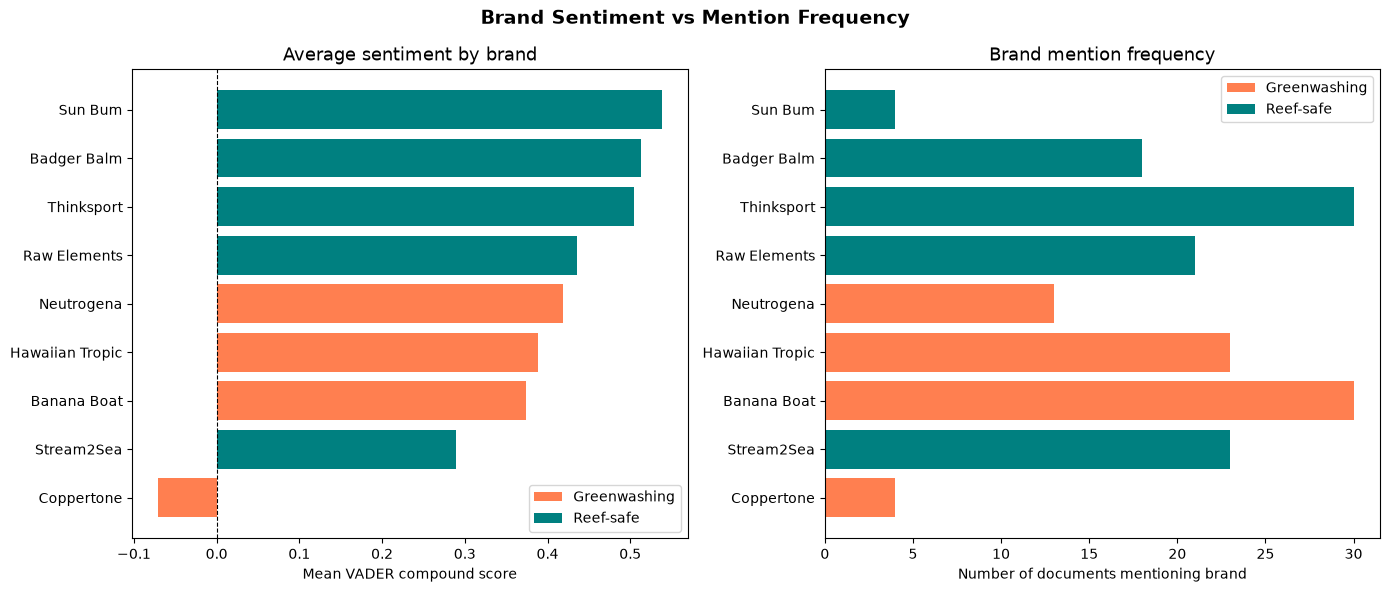

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = {'Greenwashing': 'coral', 'Reef-safe': 'teal'}

# --- barplot brand sentiment ---
bar_colors = [colors[cat] for cat in brand_df['category']]

axes[0].barh(brand_df['brand'], brand_df['mean_sentiment'], color=bar_colors)
axes[0].axvline(x=0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('Mean VADER compound score')
axes[0].set_title('Average sentiment by brand', fontsize=13)

# add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='coral', label='Greenwashing'),
                   Patch(facecolor='teal', label='Reef-safe')]
axes[0].legend(handles=legend_elements)

# --- barplot document count ---
axes[1].barh(brand_df['brand'], brand_df['count'], color=bar_colors)
axes[1].set_xlabel('Number of documents mentioning brand')
axes[1].set_title('Brand mention frequency', fontsize=13)
axes[1].legend(handles=legend_elements)

plt.suptitle('Brand Sentiment vs Mention Frequency', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Documents mentioning ACCC/Edgewell/Federal Court: 75

Sentiment distribution:
sentiment_label
positive    54
negative    20
neutral      1
Name: count, dtype: int64

Mean compound score: 0.339


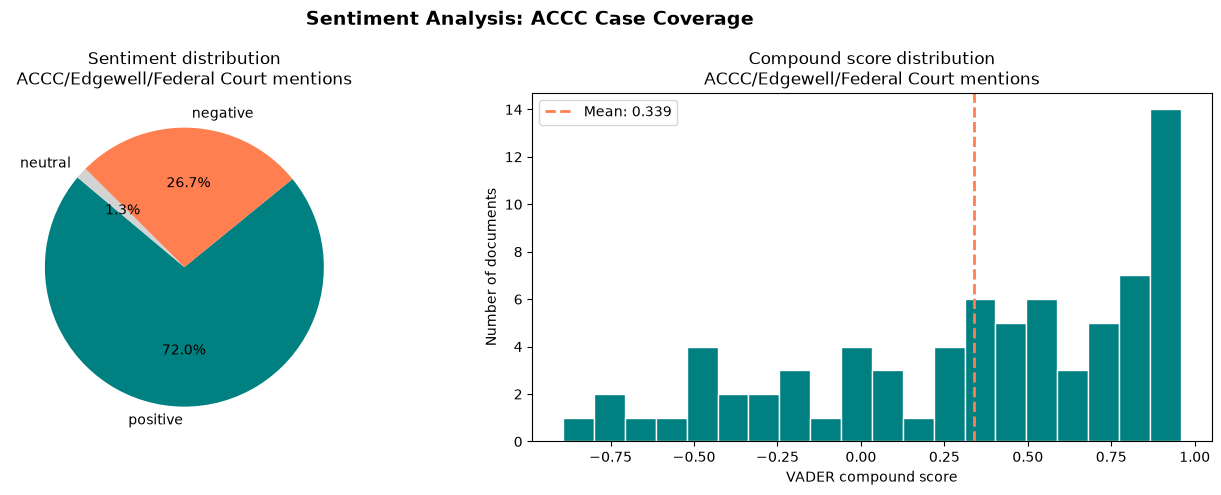

In [80]:
# filter documents mentioning ACCC
accc_mask = df['Text'].str.contains('ACCC|Edgewell|Federal Court', case=False, na=False)
df_accc = df[accc_mask].copy()

print(f"Documents mentioning ACCC/Edgewell/Federal Court: {len(df_accc)}")
print(f"\nSentiment distribution:")
print(df_accc['sentiment_label'].value_counts())
print(f"\nMean compound score: {df_accc['sentiment_score'].mean():.3f}")

# plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- pie chart sentiment distribution ---
sentiment_counts = df_accc['sentiment_label'].value_counts()
colors_pie = {'positive': 'teal', 'negative': 'coral', 'neutral': '#d3d3d3'}
pie_colors = [colors_pie[s] for s in sentiment_counts.index]

axes[0].pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    colors=pie_colors,
    startangle=140
)
axes[0].set_title('Sentiment distribution\nACCC/Edgewell/Federal Court mentions', fontsize=12)

# --- histogram of compound scores ---
axes[1].hist(df_accc['sentiment_score'], bins=20, color='teal', edgecolor='white')
axes[1].axvline(x=df_accc['sentiment_score'].mean(), color='coral', 
                linewidth=2, linestyle='--', label=f"Mean: {df_accc['sentiment_score'].mean():.3f}")
axes[1].set_xlabel('VADER compound score')
axes[1].set_ylabel('Number of documents')
axes[1].set_title('Compound score distribution\nACCC/Edgewell/Federal Court mentions', fontsize=12)
axes[1].legend()

plt.suptitle('Sentiment Analysis: ACCC Case Coverage', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [81]:
# split ACCC documents by sentiment
df_accc_neg = df_accc[df_accc['sentiment_label'] == 'negative']
df_accc_pos = df_accc[df_accc['sentiment_label'] == 'positive']

# brands to look for
brands = ['Banana Boat', 'Hawaiian Tropic', 'Neutrogena', 'Coppertone',
          'Stream2Sea', 'Raw Elements', 'Thinksport', 'Badger Balm', 'Sun Bum']

# count brand mentions in negative vs positive ACCC docs
brand_neg = {}
brand_pos = {}

for brand in brands:
    brand_neg[brand] = df_accc_neg['entities'].apply(mentions_brand, args=(brand,)).sum()
    brand_pos[brand] = df_accc_pos['entities'].apply(mentions_brand, args=(brand,)).sum()

print('Brand mentions in NEGATIVE ACCC documents:')
for brand, count in sorted(brand_neg.items(), key=lambda x: x[1], reverse=True):
    if count > 0:
        print(f'  {brand}: {count}')

print('\nBrand mentions in POSITIVE ACCC documents:')
for brand, count in sorted(brand_pos.items(), key=lambda x: x[1], reverse=True):
    if count > 0:
        print(f'  {brand}: {count}')

Brand mentions in NEGATIVE ACCC documents:
  Banana Boat: 3
  Hawaiian Tropic: 2
  Stream2Sea: 1
  Raw Elements: 1

Brand mentions in POSITIVE ACCC documents:
  Banana Boat: 13
  Hawaiian Tropic: 13
  Raw Elements: 4
  Stream2Sea: 3
  Thinksport: 2


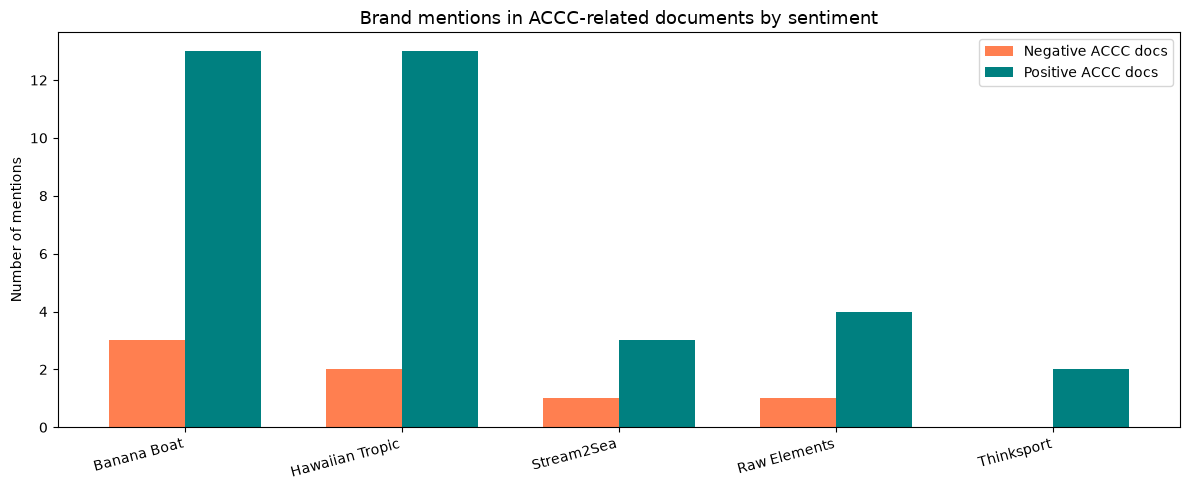

In [82]:
import numpy as np

brands_mentioned = ['Banana Boat', 'Hawaiian Tropic', 'Stream2Sea', 'Raw Elements', 'Thinksport']
neg_counts = [brand_neg[b] for b in brands_mentioned]
pos_counts = [brand_pos[b] for b in brands_mentioned]

x = np.arange(len(brands_mentioned))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))

bars1 = ax.bar(x - width/2, neg_counts, width, label='Negative ACCC docs', color='coral')
bars2 = ax.bar(x + width/2, pos_counts, width, label='Positive ACCC docs', color='teal')

ax.set_xticks(x)
ax.set_xticklabels(brands_mentioned, rotation=15, ha='right')
ax.set_ylabel('Number of mentions')
ax.set_title('Brand mentions in ACCC-related documents by sentiment', fontsize=13)
ax.legend()

plt.tight_layout()
plt.show()

In [83]:
# check the negative ACCC docs mentioning Stream2Sea
stream_neg_mask = (
    df_accc_neg['Text'].str.contains('Stream2Sea', case=False, na=False)
)
print(df_accc_neg[stream_neg_mask][['Text', 'sentiment_score', 'sentiment_label']].to_string())

                                                                                                                                                                                                                                               Text  sentiment_score sentiment_label
256  Stream2Sea was built by a marine toxicologist specifically because the greenwashing was so bad and nothing was being done about it. the fact that the ACCC case might vindicate everything she's been saying for years is genuinely satisfying          -0.2247        negative


In [84]:
# check all reef-safe brands in negative ACCC documents
reef_safe_brands = ['Stream2Sea', 'Raw Elements', 'Thinksport', 'Badger Balm', 'Sun Bum']

for brand in reef_safe_brands:
    mask = df_accc_neg['Text'].str.contains(brand, case=False, na=False)
    docs = df_accc_neg[mask]
    if len(docs) > 0:
        print(f"\n=== {brand} in NEGATIVE ACCC docs ===")
        print(docs[['Text', 'sentiment_score']].to_string())


=== Stream2Sea in NEGATIVE ACCC docs ===
                                                                                                                                                                                                                                               Text  sentiment_score
256  Stream2Sea was built by a marine toxicologist specifically because the greenwashing was so bad and nothing was being done about it. the fact that the ACCC case might vindicate everything she's been saying for years is genuinely satisfying          -0.2247

=== Raw Elements in NEGATIVE ACCC docs ===
                                                                                                                                                                                                                                                                                                                                                                                                        

### Qualitative Insight: Reef-safe Brands in Negative Documents

Manual inspection of the 2 negative ACCC-related documents mentioning 
reef-safe brands reveals a consistent pattern:

- **Stream2Sea** appears in a document critical of the greenwashing 
  industry, cited as a brand built specifically to address the problem
- **Raw Elements** appears in a document expressing betrayal toward 
  Banana Boat, cited as the trusted alternative after switching

In both cases, negative sentiment is directed toward greenwashing brands 
and the regulatory failure, not toward the reef-safe brands themselves. 
This suggests that reef-safe brands benefit from negative sentiment 
toward competitors: consumer anger at greenwashing directly drives 
consideration of genuine alternatives.

**This is the key strategic insight for Stream2Sea.**

In [85]:
# check what's actually said about Stream2Sea in the dataset
stream_mask = df['Text'].str.contains('Stream2Sea', case=False, na=False)
print(df[stream_mask][['Text', 'is_synthetic']].to_string())

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       Text  is_synthetic
8                                                                               ACCC just dropped the hammer on Banana Boat and Hawaiian Tropic - Federal Court proceedings for greenwashing!! Finally someone is doing something about these 'reef friendly' 

In [86]:
df.to_csv('../data/processed/df_sunscreen_final.csv', index=False)
print(f"✓ Saved: {df.shape}")

✓ Saved: (268, 16)


## Preliminary Findings

_Full conclusions after RoBERTa comparison in notebook 05._

### Methodological Limitations

Sentiment analysis was performed using VADER, a rule-based lexicon 
designed for social media text. While appropriate for informal Reddit 
content, VADER has two key limitations relevant to this dataset:

1. **Sarcasm detection**: VADER cannot distinguish sarcastic positivity 
   from genuine positivity. Approximately 19% of synthetic data (batch 5) 
   was intentionally sarcastic, which likely inflated positive sentiment counts.

2. **Domain-specific context**: terms like *thick* or *white cast* carry 
   connotations specific to the reef-safe sunscreen domain that VADER's 
   general lexicon cannot capture.

A transformer-based model (RoBERTa fine-tuned on social media sentiment) 
would address both limitations - tested in notebook 05.

## Next Step: RoBERTa Sentiment Analysis

VADER's limitations with sarcasm and domain-specific context are addressed 
in notebook 05 using `cardiffnlp/twitter-roberta-base-sentiment`, 
a transformer model fine-tuned on social media text.

This allows a direct comparison between rule-based (VADER) and 
transformer-based sentiment classification on the same corpus.

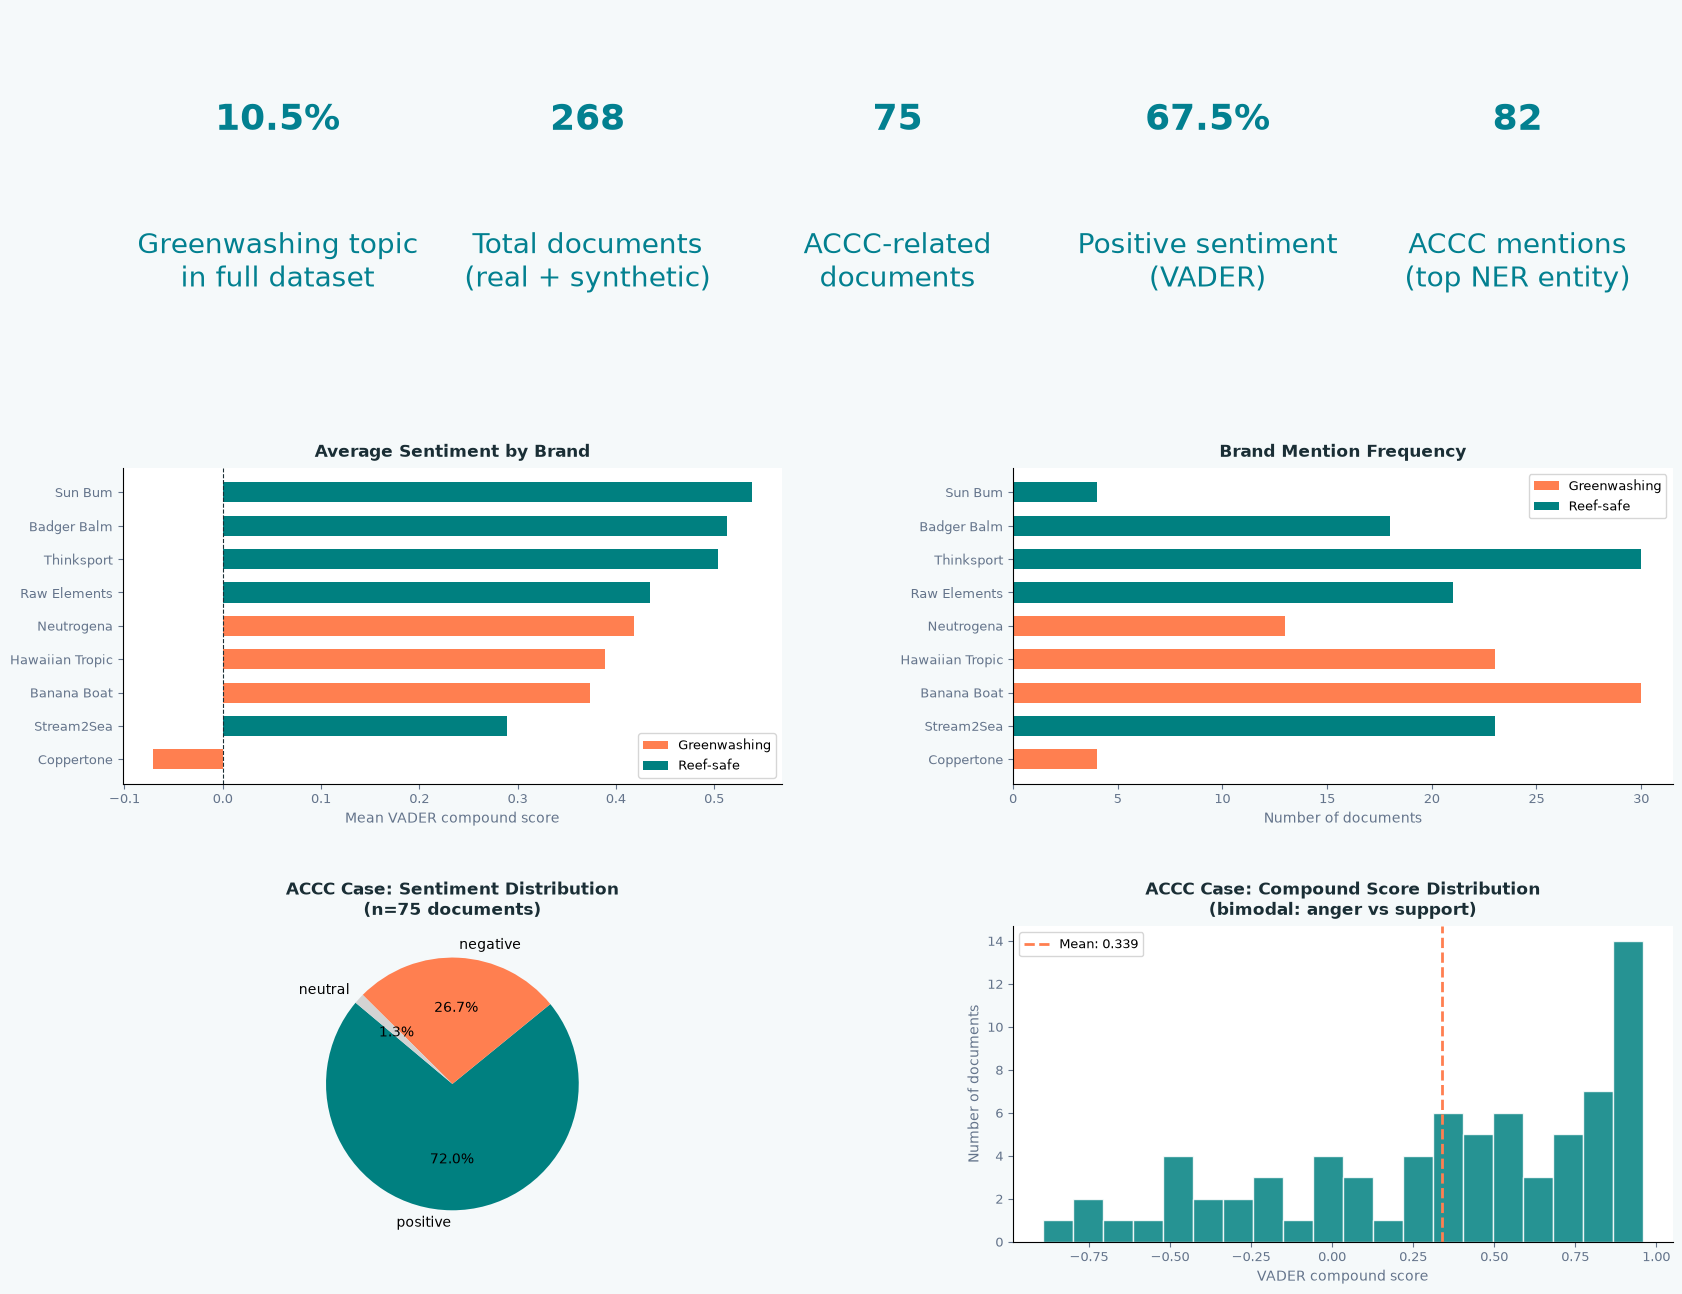

✓ Dashboard saved as ../figures/dashboard.png


In [87]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from matplotlib.patches import Patch

fig = plt.figure(figsize=(20, 16))
fig.patch.set_facecolor('#F5F9FA')

gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── KPI BAR ──────────────────────────────────────────────────────
ax_kpi = fig.add_subplot(gs[0, :])
ax_kpi.set_facecolor('#1A2E35')
ax_kpi.axis('off')

kpis = [
    ("10.5%", "Greenwashing topic\nin full dataset"),
    ("268", "Total documents\n(real + synthetic)"),
    ("75", "ACCC-related\ndocuments"),
    ("67.5%", "Positive sentiment\n(VADER)"),
    ("82", "ACCC mentions\n(top NER entity)"),
]

for i, (val, label) in enumerate(kpis):
    x = 0.1 + i * 0.2
    ax_kpi.text(x, 0.65, val, transform=ax_kpi.transAxes,
                fontsize=26, fontweight='bold', color='#028090',
                ha='center', va='center')
    ax_kpi.text(x, 0.2, label, transform=ax_kpi.transAxes,
                fontsize=20, color='#028090',
                ha='center', va='center')


# ── BRAND SENTIMENT ───────────────────────────────────────────────
ax1 = fig.add_subplot(gs[1, 0])
ax1.set_facecolor('white')

colors_bar = ['coral' if c == 'Greenwashing' else 'teal'
              for c in brand_df['category']]
bars = ax1.barh(brand_df['brand'], brand_df['mean_sentiment'],
                color=colors_bar, height=0.6)
ax1.axvline(x=0, color='#1A2E35', linewidth=0.8, linestyle='--')
ax1.set_xlabel('Mean VADER compound score', fontsize=10, color='#64748B')
ax1.set_title('Average Sentiment by Brand', fontsize=12,
              fontweight='bold', color='#1A2E35', pad=8)
ax1.tick_params(colors='#64748B', labelsize=9)
ax1.spines[['top', 'right']].set_visible(False)
legend_elements = [Patch(facecolor='coral', label='Greenwashing'),
                   Patch(facecolor='teal', label='Reef-safe')]
ax1.legend(handles=legend_elements, fontsize=9)

# ── BRAND MENTION FREQUENCY ───────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 1])
ax2.set_facecolor('white')

ax2.barh(brand_df['brand'], brand_df['count'],
         color=colors_bar, height=0.6)
ax2.set_xlabel('Number of documents', fontsize=10, color='#64748B')
ax2.set_title('Brand Mention Frequency', fontsize=12,
              fontweight='bold', color='#1A2E35', pad=8)
ax2.tick_params(colors='#64748B', labelsize=9)
ax2.spines[['top', 'right']].set_visible(False)
ax2.legend(handles=legend_elements, fontsize=9)

# ── ACCC PIE CHART ────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2, 0])
ax3.set_facecolor('white')

sentiment_counts = df_accc['sentiment_label'].value_counts()
pie_colors = {'positive': 'teal', 'negative': 'coral', 'neutral': '#d3d3d3'}
colors_pie = [pie_colors[s] for s in sentiment_counts.index]

ax3.pie(sentiment_counts.values,
        labels=sentiment_counts.index,
        autopct='%1.1f%%',
        colors=colors_pie,
        startangle=140,
        textprops={'fontsize': 10})
ax3.set_title('ACCC Case: Sentiment Distribution\n(n=75 documents)',
              fontsize=12, fontweight='bold', color='#1A2E35', pad=8)

# ── ACCC HISTOGRAM ────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 1])
ax4.set_facecolor('white')

ax4.hist(df_accc['sentiment_score'], bins=20,
         color='teal', edgecolor='white', alpha=0.85)
ax4.axvline(x=df_accc['sentiment_score'].mean(),
            color='coral', linewidth=2, linestyle='--',
            label=f"Mean: {df_accc['sentiment_score'].mean():.3f}")
ax4.set_xlabel('VADER compound score', fontsize=10, color='#64748B')
ax4.set_ylabel('Number of documents', fontsize=10, color='#64748B')
ax4.set_title('ACCC Case: Compound Score Distribution\n(bimodal: anger vs support)',
              fontsize=12, fontweight='bold', color='#1A2E35', pad=8)
ax4.spines[['top', 'right']].set_visible(False)
ax4.tick_params(colors='#64748B', labelsize=9)
ax4.legend(fontsize=9)

plt.savefig('../figures/dashboard.png', dpi=150, bbox_inches='tight',
            facecolor='#F5F9FA')
plt.show()
print("✓ Dashboard saved as ../figures/dashboard.png")